# Crawler Benchmark Analysis

This notebook analyzes Toy FS crawler benchmark CSV files produced by `bench/run_docker_matrix.sh`.

It focuses on:

- throughput and wall time by thread count;
- speedup and saturation points;
- model A vs model B trade-offs;
- CPU utilization and context-switch overhead;
- cases where split-pool traversal helps or hurts.


In [40]:
from pathlib import Path
import csv
import math
import statistics

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'matplotlib is required for plots. In a notebook cell, run: %pip install -r bench/requirements.txt '
        'or: %pip install matplotlib'
    ) from exc

RESULTS_DIR = Path('../bench_results_matrix_20k')
CSV_FILES = sorted(RESULTS_DIR.glob('*/results.csv'))

print('results dir:', RESULTS_DIR.resolve())
print('csv files:')
for path in CSV_FILES:
    print(' -', path)


results dir: /home/p0tniy/Documents/projects/toy-fs-utils/bench_results_matrix_20k
csv files:
 - ../bench_results_matrix_20k/deep/results.csv
 - ../bench_results_matrix_20k/mixed/results.csv
 - ../bench_results_matrix_20k/wide/results.csv


## Load Raw Rows

Rows with non-zero `rc` are kept visible in `bad_rows`, but excluded from the median summary.


In [41]:
def load_rows(paths):
    rows = []
    for path in paths:
        with path.open(newline='') as f:
            reader = csv.DictReader(f)
            for row in reader:
                row = dict(row)
                row['source_csv'] = str(path)
                row['run'] = int(row['run'])
                row['threads'] = int(row['threads'])
                row['entries'] = int(row['entries'])
                row['wall_ms'] = float(row['wall_ms'])
                row['cpu_ms'] = float(row['cpu_ms'])
                row['cpu_util'] = float(row['cpu_util'])
                row['throughput'] = float(row['throughput'])
                row['vol_cs'] = float(row['vol_cs'])
                row['invol_cs'] = float(row['invol_cs'])
                row['bytes'] = int(row['bytes'])
                row['checksum'] = int(row['checksum'])
                row['rc'] = int(row['rc'])
                rows.append(row)
    return rows

rows = load_rows(CSV_FILES)
bad_rows = [r for r in rows if r['rc'] != 0]
ok_rows = [r for r in rows if r['rc'] == 0]

print('total rows:', len(rows))
print('ok rows:', len(ok_rows))
print('bad rows:', len(bad_rows))
print('trees:', sorted({r['tree'] for r in ok_rows}))
print('callbacks:', sorted({r['callback'] for r in ok_rows}))
print('models:', sorted({r['model'] for r in ok_rows}))
print('threads:', sorted({r['threads'] for r in ok_rows}))


total rows: 585
ok rows: 585
bad rows: 0
trees: ['deep', 'mixed', 'wide']
callbacks: ['cheap', 'heavy', 'stat']
models: ['A', 'B']
threads: [1, 2, 4, 6, 8, 12, 16]


## Median Summary

Benchmarks are noisy, so the analysis uses medians over repeated runs.


In [42]:
def median(values):
    return statistics.median(values) if values else float('nan')

def group_key(row):
    return (row['tree'], row['callback'], row['model'], row['threads'])

groups = {}
for row in ok_rows:
    groups.setdefault(group_key(row), []).append(row)

summary = []
for (tree, callback, model, threads), group in sorted(groups.items()):
    item = {
        'tree': tree,
        'callback': callback,
        'model': model,
        'threads': threads,
        'runs': len(group),
        'entries': int(median([r['entries'] for r in group])),
        'wall_ms': median([r['wall_ms'] for r in group]),
        'cpu_ms': median([r['cpu_ms'] for r in group]),
        'cpu_util': median([r['cpu_util'] for r in group]),
        'throughput': median([r['throughput'] for r in group]),
        'vol_cs': median([r['vol_cs'] for r in group]),
        'invol_cs': median([r['invol_cs'] for r in group]),
    }
    summary.append(item)

baseline = {}
for item in summary:
    k = (item['tree'], item['callback'], item['model'])
    if k not in baseline or item['threads'] < baseline[k]['threads']:
        baseline[k] = item

for item in summary:
    base = baseline[(item['tree'], item['callback'], item['model'])]
    item['speedup'] = base['wall_ms'] / item['wall_ms']

summary[:3]


[{'tree': 'deep',
  'callback': 'cheap',
  'model': 'A',
  'threads': 2,
  'runs': 5,
  'entries': 20205,
  'wall_ms': 61.433,
  'cpu_ms': 89.799,
  'cpu_util': 1.464,
  'throughput': 328894.422,
  'vol_cs': 8858.0,
  'invol_cs': 5.0,
  'speedup': 1.0},
 {'tree': 'deep',
  'callback': 'cheap',
  'model': 'A',
  'threads': 4,
  'runs': 5,
  'entries': 20205,
  'wall_ms': 69.793,
  'cpu_ms': 170.544,
  'cpu_util': 2.462,
  'throughput': 289498.905,
  'vol_cs': 21418.0,
  'invol_cs': 19.0,
  'speedup': 0.8802172137606923},
 {'tree': 'deep',
  'callback': 'cheap',
  'model': 'A',
  'threads': 6,
  'runs': 5,
  'entries': 20205,
  'wall_ms': 68.402,
  'cpu_ms': 246.069,
  'cpu_util': 3.511,
  'throughput': 295385.819,
  'vol_cs': 22689.0,
  'invol_cs': 77.0,
  'speedup': 0.8981170141223941}]

In [43]:
def rows_for(tree=None, callback=None, model=None):
    data = summary
    if tree is not None:
        data = [r for r in data if r['tree'] == tree]
    if callback is not None:
        data = [r for r in data if r['callback'] == callback]
    if model is not None:
        data = [r for r in data if r['model'] == model]
    return sorted(data, key=lambda r: (r['tree'], r['callback'], r['model'], r['threads']))

def print_table(data, columns):
    widths = {c: max(len(c), *(len(f'{r[c]:.3f}') if isinstance(r[c], float) else len(str(r[c])) for r in data)) for c in columns}
    print(' | '.join(c.ljust(widths[c]) for c in columns))
    print(' | '.join('-' * widths[c] for c in columns))
    for r in data:
        cells = []
        for c in columns:
            v = r[c]
            cells.append((f'{v:.3f}' if isinstance(v, float) else str(v)).rjust(widths[c]))
        print(' | '.join(cells))

print_table(rows_for(), ['tree', 'callback', 'model', 'threads', 'runs', 'wall_ms', 'speedup', 'throughput', 'cpu_util', 'vol_cs', 'invol_cs'])


tree  | callback | model | threads | runs | wall_ms  | speedup | throughput  | cpu_util | vol_cs    | invol_cs
----- | -------- | ----- | ------- | ---- | -------- | ------- | ----------- | -------- | --------- | --------
 deep |    cheap |     A |       2 |    5 |   61.433 |   1.000 |  328894.422 |    1.464 |  8858.000 |    5.000
 deep |    cheap |     A |       4 |    5 |   69.793 |   0.880 |  289498.905 |    2.462 | 21418.000 |   19.000
 deep |    cheap |     A |       6 |    5 |   68.402 |   0.898 |  295385.819 |    3.511 | 22689.000 |   77.000
 deep |    cheap |     A |       8 |    5 |   77.093 |   0.797 |  262086.093 |    4.668 | 23923.000 |   88.000
 deep |    cheap |     A |      12 |    5 |   64.246 |   0.956 |  314491.855 |    6.486 | 23913.000 |  216.000
 deep |    cheap |     A |      16 |    5 |   54.828 |   1.120 |  368517.895 |    6.500 | 21100.000 | 1084.000
 deep |    cheap |     B |       1 |    5 |   63.045 |   1.000 |  320487.106 |    0.990 |     1.000 |    4.000
 

## Plot Helpers


In [44]:
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

def plot_metric(metric, ylabel=None):
    trees = sorted({r['tree'] for r in summary})
    callbacks = sorted({r['callback'] for r in summary})
    fig, axes = plt.subplots(len(trees), len(callbacks), figsize=(5 * len(callbacks), 4 * len(trees)), squeeze=False)
    for i, tree in enumerate(trees):
        for j, callback in enumerate(callbacks):
            ax = axes[i][j]
            for model in sorted({r['model'] for r in summary}):
                data = rows_for(tree=tree, callback=callback, model=model)
                if not data:
                    continue
                ax.plot([r['threads'] for r in data], [r[metric] for r in data], marker='o', label=f'model {model}')
            ax.set_title(f'{tree} / {callback}')
            ax.set_xlabel('threads')
            ax.set_ylabel(ylabel or metric)
            ax.legend()
    fig.tight_layout()
    return fig


## Wall Time

Lower is better. This is the clearest view of end-to-end performance.


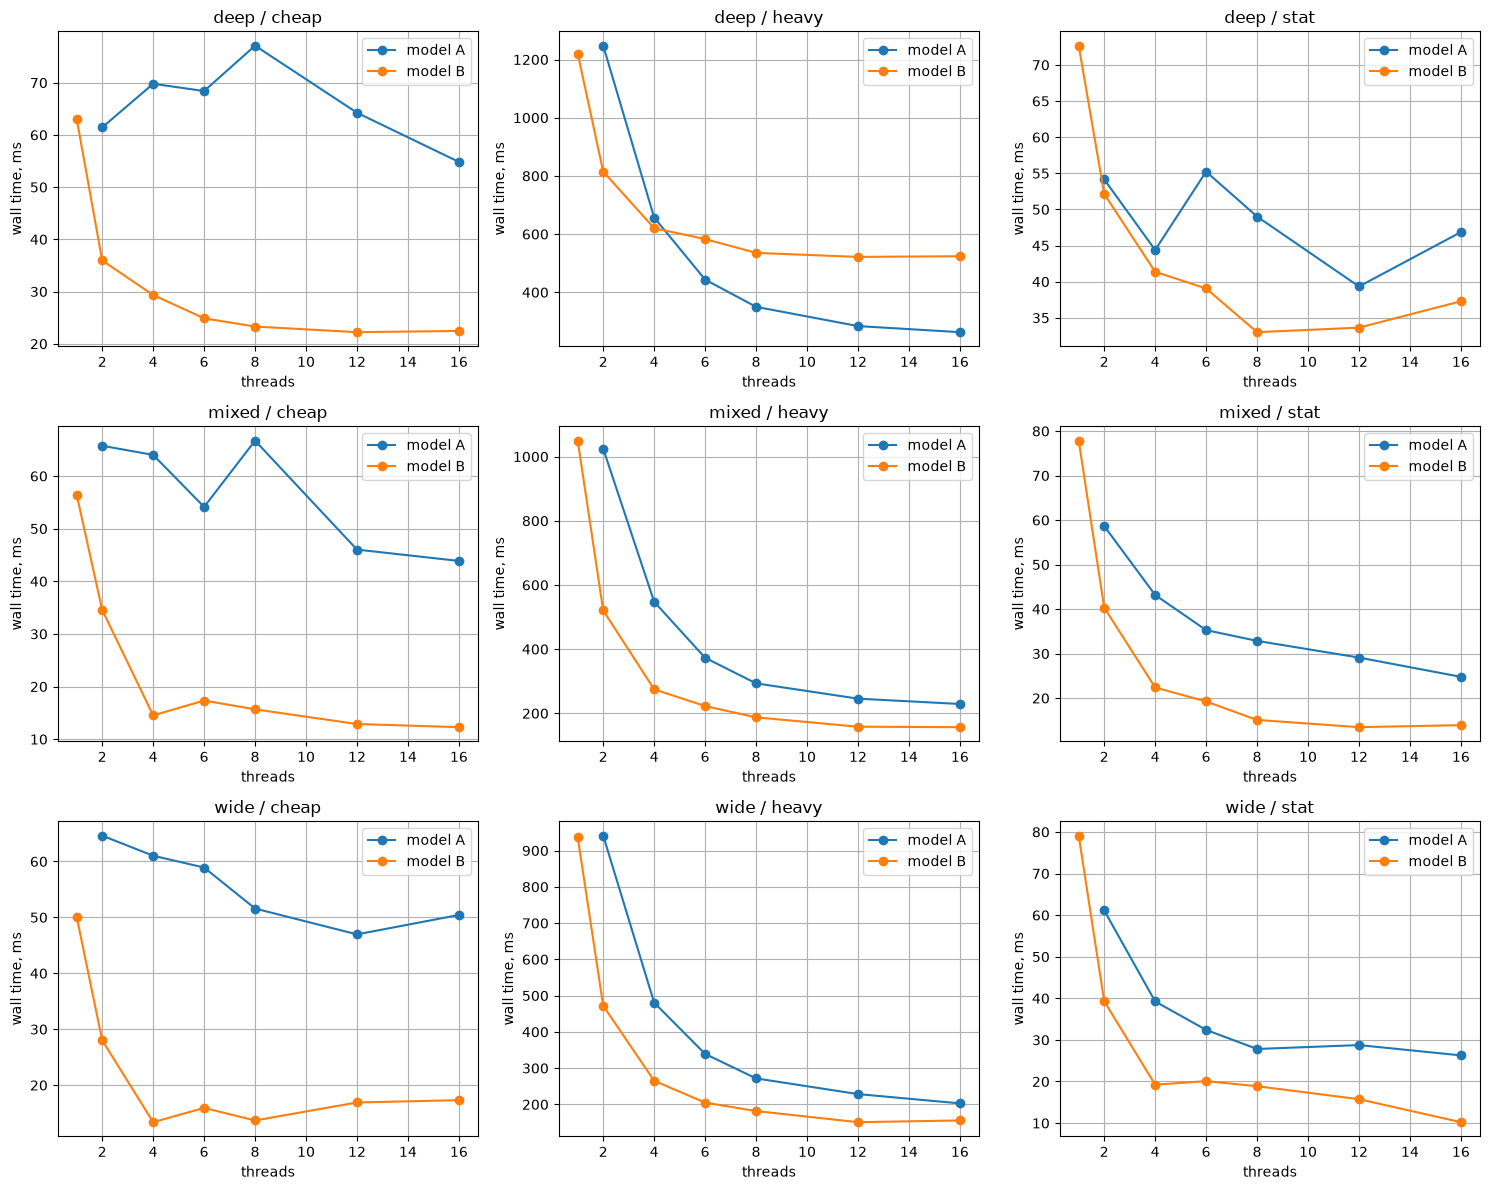

In [45]:
plot_metric('wall_ms', 'wall time, ms');


## Throughput

Higher is better. This is `entries / wall_sec`.


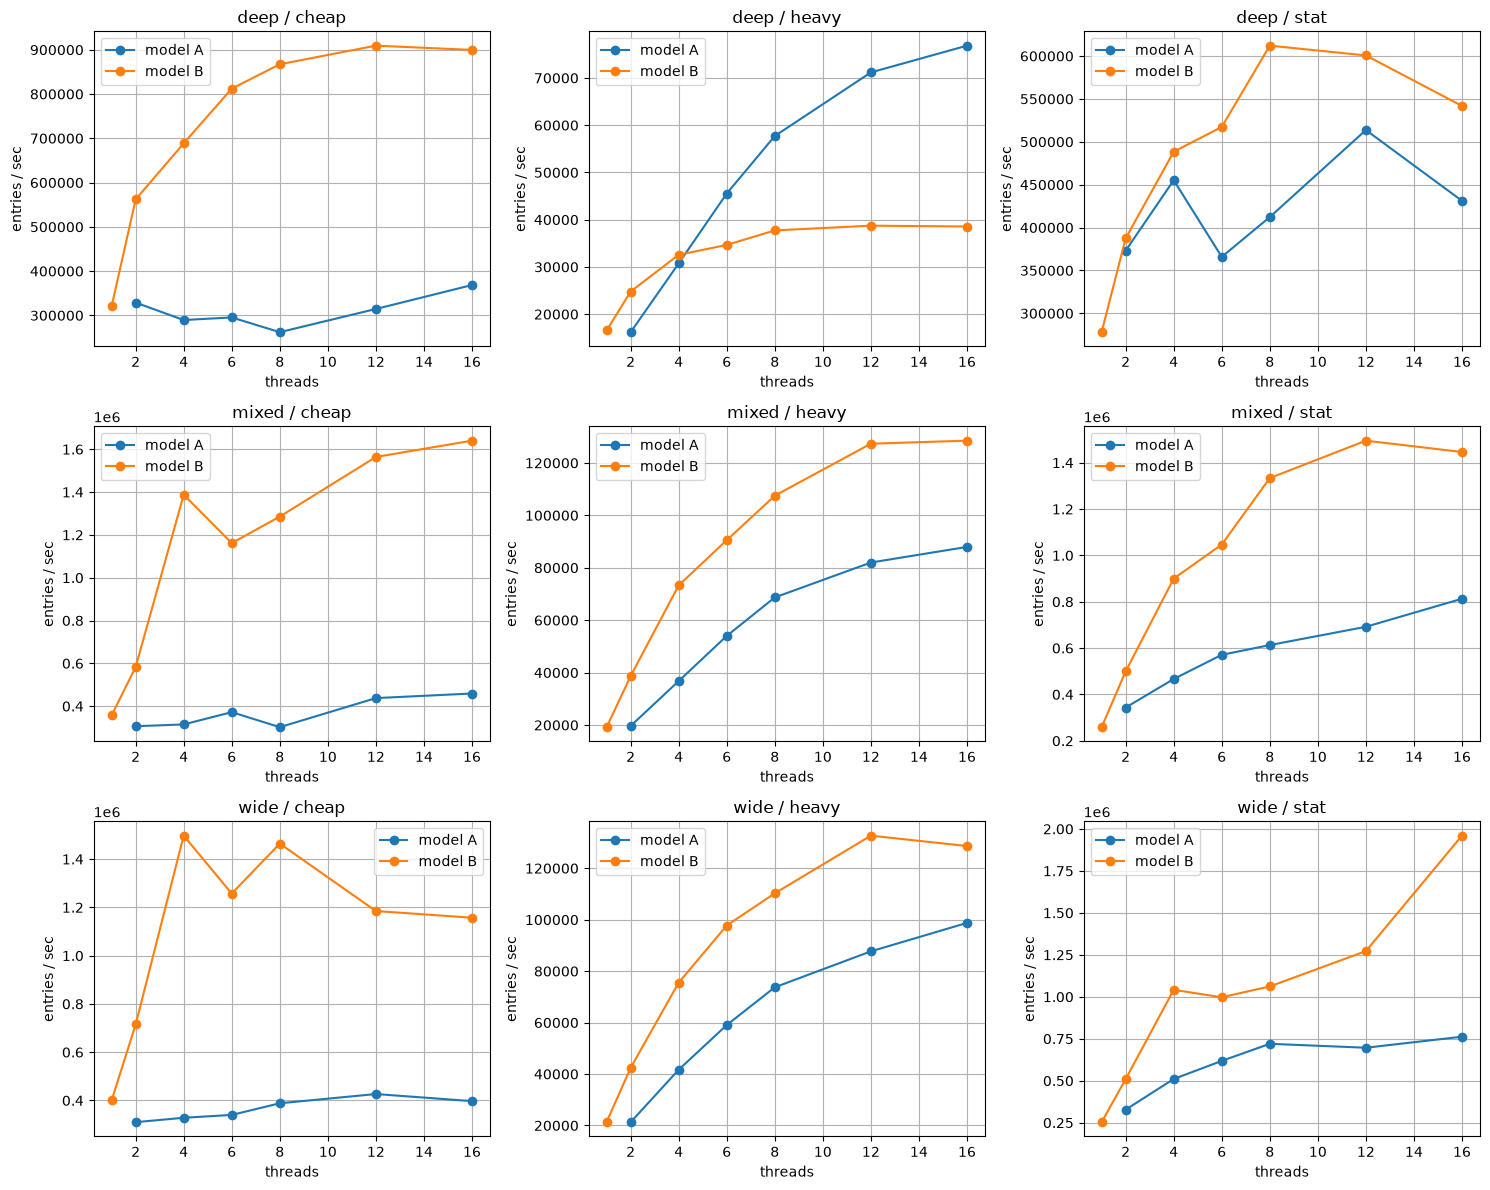

In [46]:
plot_metric('throughput', 'entries / sec');


## Speedup

Speedup is relative to the lowest thread count available for that model. For model A this is usually 2 threads, because split-pool cannot be represented honestly with one worker.


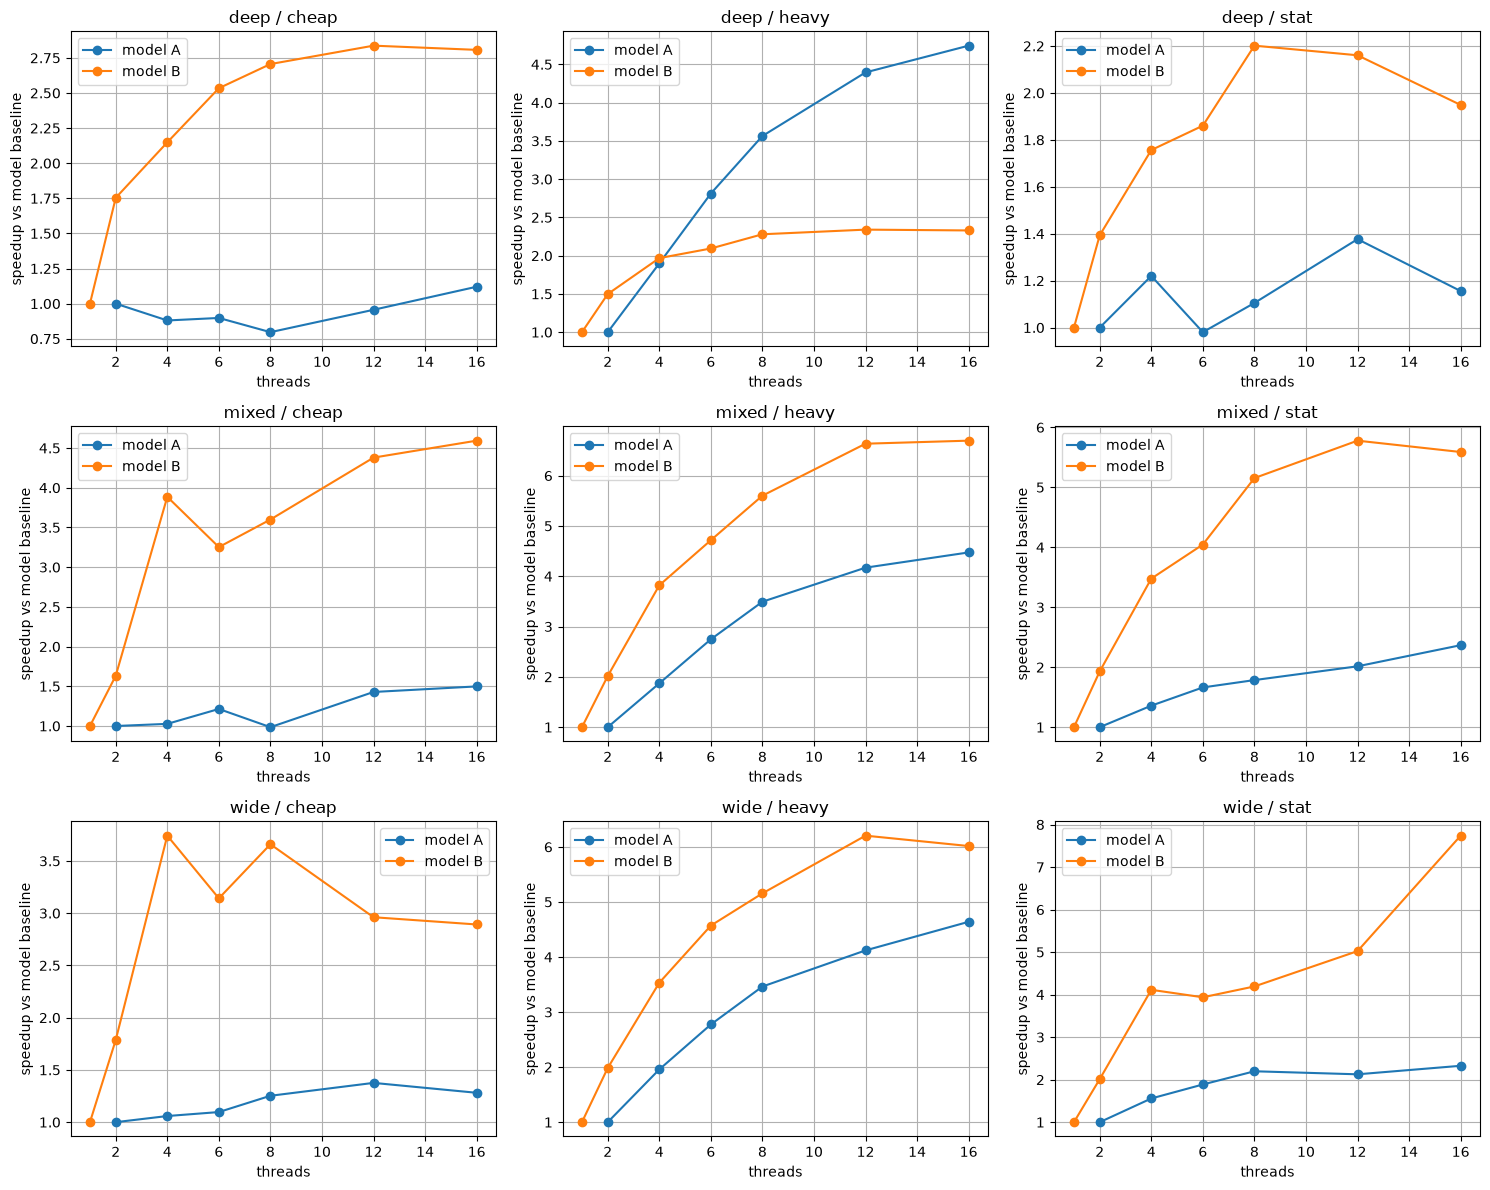

In [47]:
plot_metric('speedup', 'speedup vs model baseline');


## CPU Utilization

`cpu_util = process_cpu_ms / wall_ms`. Values greater than 1 mean the process used multiple cores.


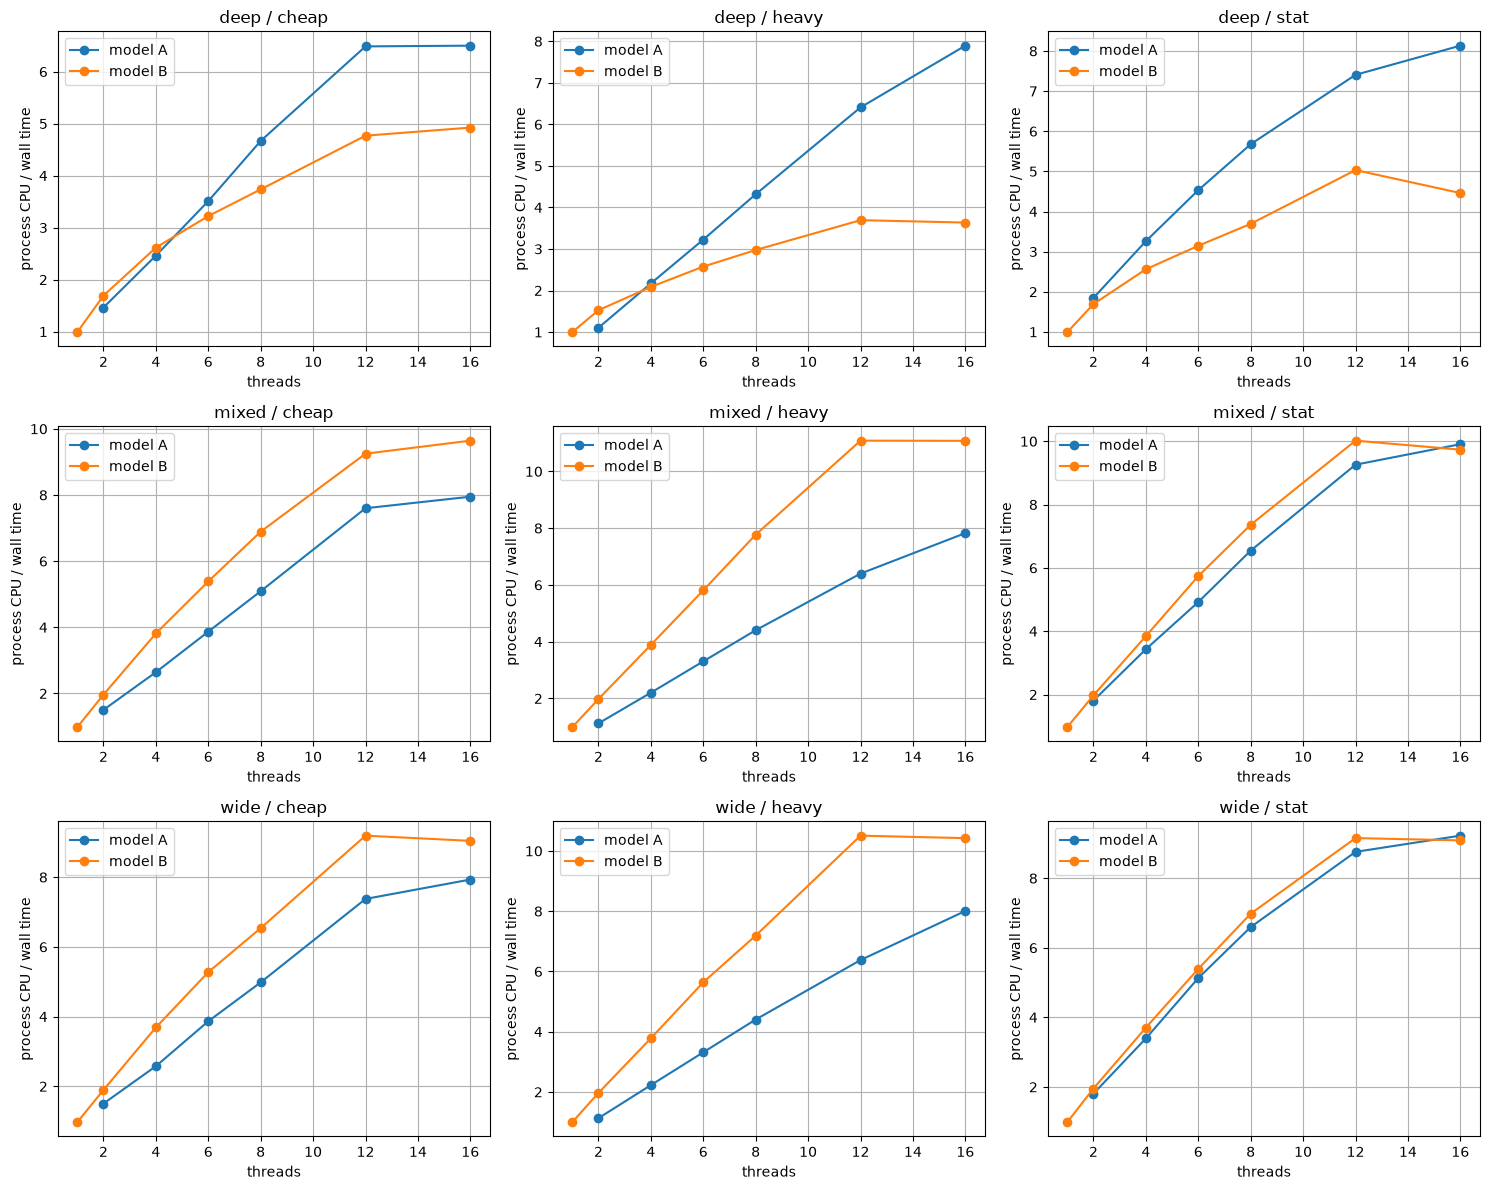

In [48]:
plot_metric('cpu_util', 'process CPU / wall time');


## Context Switches

Large voluntary context-switch counts are a useful signal for queue handoff and blocking overhead.


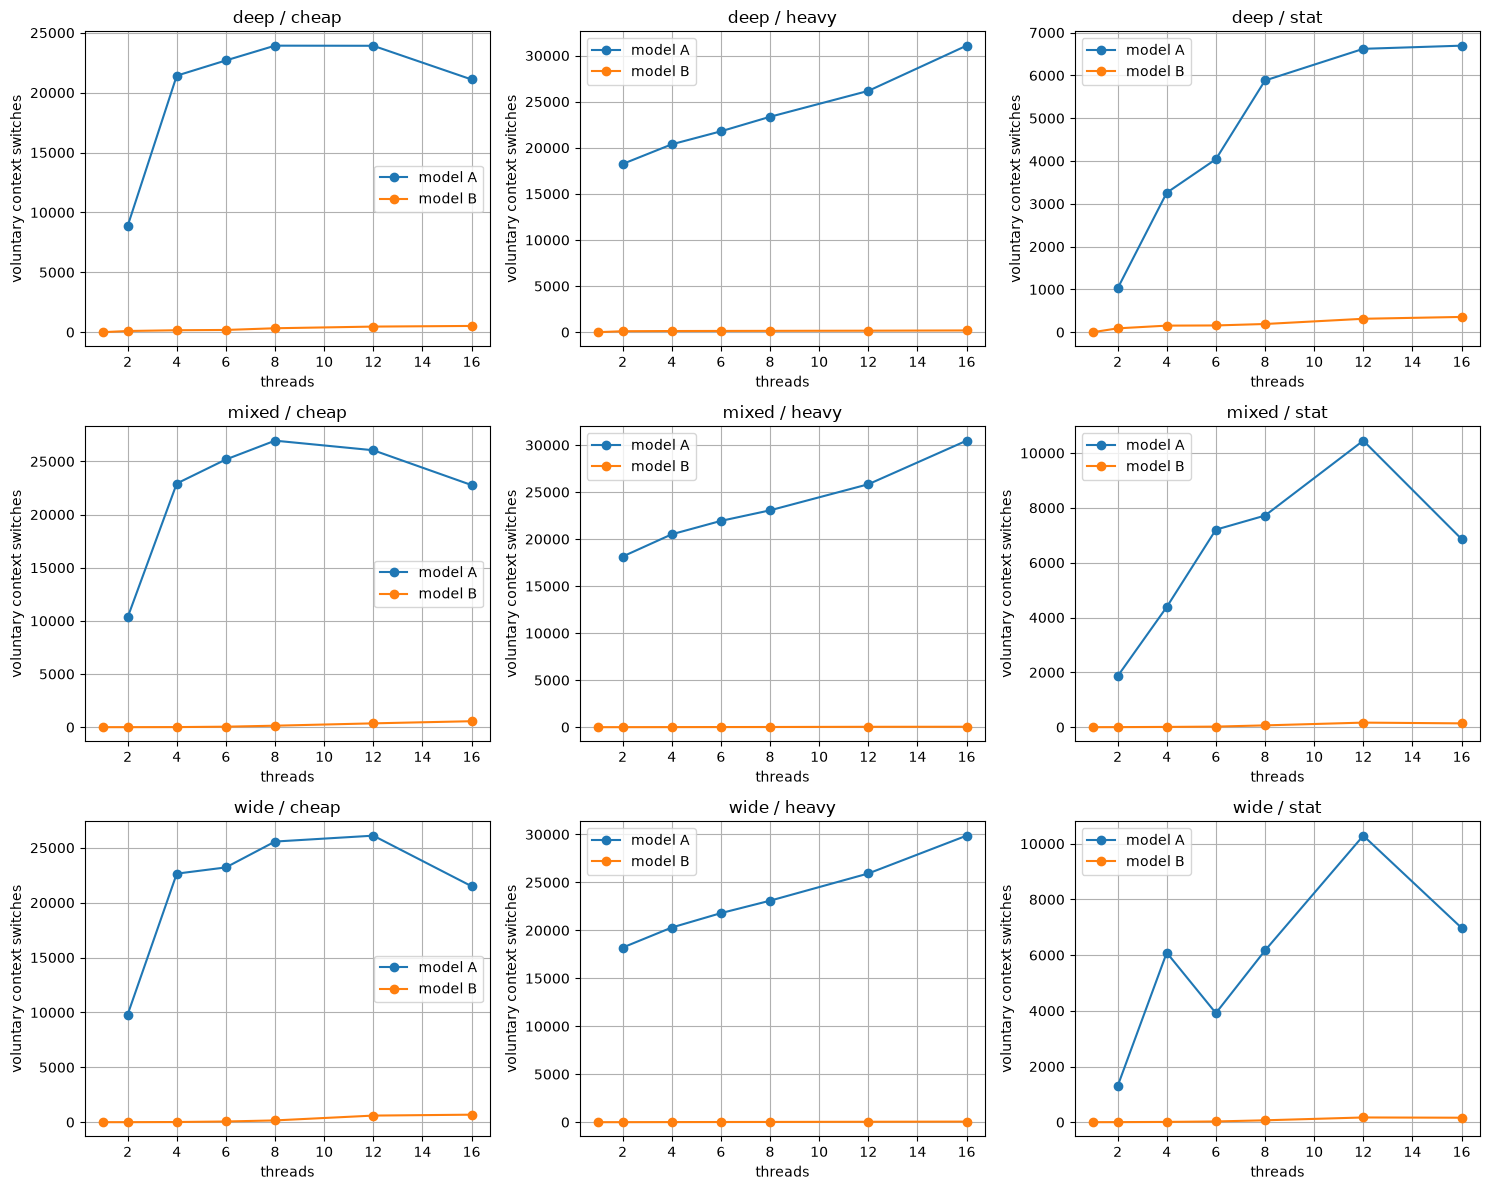

In [49]:
plot_metric('vol_cs', 'voluntary context switches');


## A vs B Ratio

`A/B wall ratio > 1` means model A is slower. `< 1` means model A is faster.


tree  | callback | threads | a_wall   | b_wall  | a_over_b
----- | -------- | ------- | -------- | ------- | --------
 deep |    cheap |       2 |   61.433 |  35.954 |    1.709
 deep |    cheap |       4 |   69.793 |  29.341 |    2.379
 deep |    cheap |       6 |   68.402 |  24.878 |    2.749
 deep |    cheap |       8 |   77.093 |  23.297 |    3.309
 deep |    cheap |      12 |   64.246 |  22.221 |    2.891
 deep |    cheap |      16 |   54.828 |  22.458 |    2.441
 deep |    heavy |       2 | 1247.675 | 814.951 |    1.531
 deep |    heavy |       4 |  657.033 | 620.301 |    1.059
 deep |    heavy |       6 |  443.668 | 583.020 |    0.761
 deep |    heavy |       8 |  350.073 | 535.476 |    0.654
 deep |    heavy |      12 |  283.876 | 521.612 |    0.544
 deep |    heavy |      16 |  262.956 | 524.007 |    0.502
 deep |     stat |       2 |   54.154 |  52.148 |    1.038
 deep |     stat |       4 |   44.385 |  41.368 |    1.073
 deep |     stat |       6 |   55.231 |  39.059 |    1.4

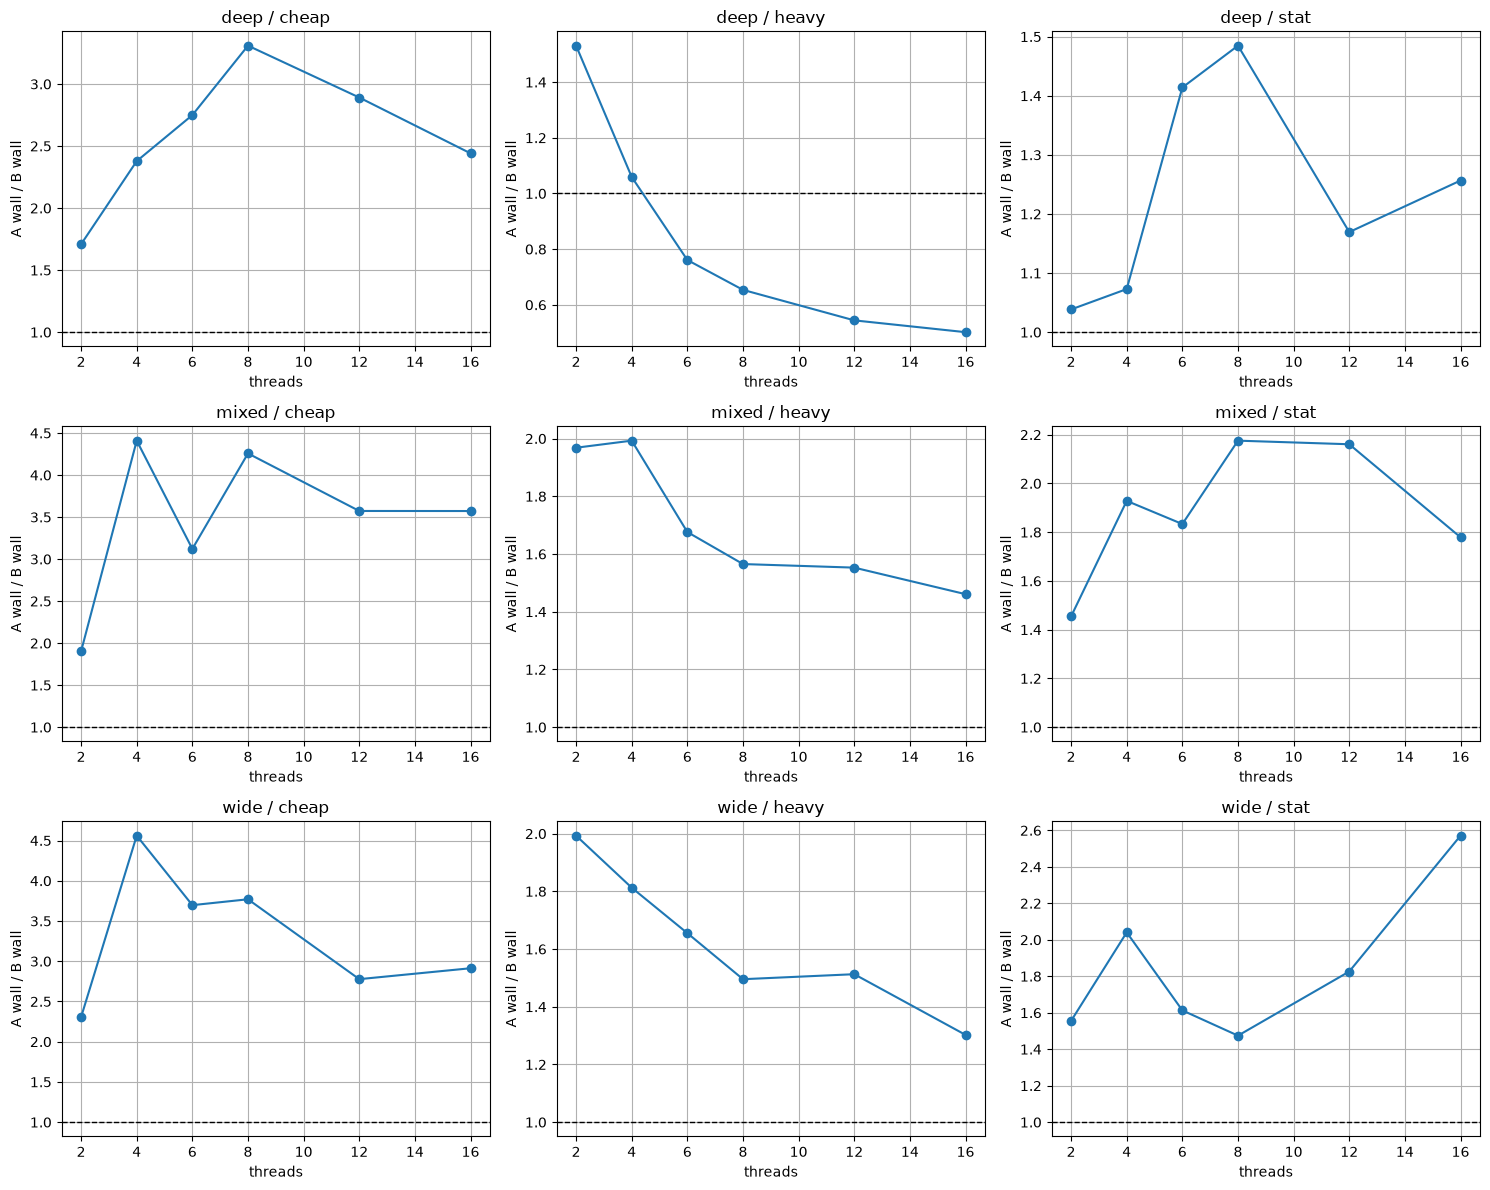

In [50]:
ratios = []
index = {(r['tree'], r['callback'], r['model'], r['threads']): r for r in summary}
for a in summary:
    if a['model'] != 'A':
        continue
    b = index.get((a['tree'], a['callback'], 'B', a['threads']))
    if not b:
        continue
    ratios.append({
        'tree': a['tree'],
        'callback': a['callback'],
        'threads': a['threads'],
        'a_wall': a['wall_ms'],
        'b_wall': b['wall_ms'],
        'a_over_b': a['wall_ms'] / b['wall_ms'],
    })

print_table(ratios, ['tree', 'callback', 'threads', 'a_wall', 'b_wall', 'a_over_b'])

trees = sorted({r['tree'] for r in ratios})
callbacks = sorted({r['callback'] for r in ratios})
fig, axes = plt.subplots(len(trees), len(callbacks), figsize=(5 * len(callbacks), 4 * len(trees)), squeeze=False)
for i, tree in enumerate(trees):
    for j, callback in enumerate(callbacks):
        ax = axes[i][j]
        data = sorted([r for r in ratios if r['tree'] == tree and r['callback'] == callback], key=lambda r: r['threads'])
        ax.axhline(1.0, color='black', linewidth=1, linestyle='--')
        ax.plot([r['threads'] for r in data], [r['a_over_b'] for r in data], marker='o')
        ax.set_title(f'{tree} / {callback}')
        ax.set_xlabel('threads')
        ax.set_ylabel('A wall / B wall')
fig.tight_layout();


## Best Configurations


In [51]:
best = []
for tree in sorted({r['tree'] for r in summary}):
    for callback in sorted({r['callback'] for r in summary}):
        data = rows_for(tree=tree, callback=callback)
        winner = min(data, key=lambda r: r['wall_ms'])
        best.append(winner)

print_table(best, ['tree', 'callback', 'model', 'threads', 'wall_ms', 'throughput', 'cpu_util', 'vol_cs', 'invol_cs'])


tree  | callback | model | threads | wall_ms | throughput  | cpu_util | vol_cs    | invol_cs
----- | -------- | ----- | ------- | ------- | ----------- | -------- | --------- | --------
 deep |    cheap |     B |      12 |  22.221 |  909282.867 |    4.769 |   467.000 |   27.000
 deep |    heavy |     A |      16 | 262.956 |   76837.821 |    7.895 | 31074.000 |  903.000
 deep |     stat |     B |       8 |  33.009 |  612102.971 |    3.693 |   192.000 |   22.000
mixed |    cheap |     B |      16 |  12.282 | 1640059.796 |    9.643 |   562.000 |  100.000
mixed |    heavy |     B |      16 | 156.780 |  128486.045 |   11.077 |    45.000 |  651.000
mixed |     stat |     B |      12 |  13.473 | 1495152.963 |   10.020 |   167.000 |   33.000
 wide |    cheap |     B |       4 |  13.380 | 1497136.666 |    3.690 |    15.000 |   12.000
 wide |    heavy |     B |      12 | 150.985 |  132675.366 |   10.508 |    43.000 |  353.000
 wide |     stat |     B |      16 |  10.221 | 1959864.457 |    9.088 

## Findings From The 20k Docker Matrix

Test context: `wide`, `mixed`, and `deep` fixtures with 20k files; callbacks `cheap`, `stat`, and `heavy`; thread counts `1, 2, 4, 6, 8, 12, 16`; 5 measured runs per combination.

- Model B, the current one-pool crawler, wins most cheap and stat workloads. It avoids the extra queue handoff between traversal and processing, so it has much lower synchronization overhead.
- Model A, the split-pool crawler, produces dramatically more voluntary context switches on cheap callbacks. This is a strong sign that many entries are paying for cross-pool queueing and wakeups instead of useful work.
- Model B usually scales well until roughly 8-12 threads on this machine, then reaches a plateau or regresses. That matches the `nproc=12` environment metadata and suggests the extra workers mostly add contention after that point.
- Model A clearly wins on `deep/heavy`: traversal and callback execution are decoupled, so processing workers can keep chewing CPU-heavy callbacks while traversal workers continue exposing new work.
- Deep trees expose a traversal-frontier bottleneck more strongly than wide or mixed trees. With heavy callbacks, model B workers can get stuck doing callback work before enough new directory tasks are discovered.
- The architectural trade-off is not simply 'more pools are faster'. Split pools help when processing is heavy and traversal can otherwise be blocked, but they hurt when callbacks are cheap because queue handoff dominates.

Current takeaway: keep model B as the production crawler architecture for general-purpose filesystem utilities. Treat model A as a specialized design worth considering only for workloads with expensive callbacks or pipeline stages that should be isolated from traversal.
